# Atividade — Histograma e operações de contraste

Foram escolhidas três imagens:

1. **Imagem escura:** foto da televisão em ambiente interno com pouca iluminação.
2. **Imagem clara/flash:** foto do gato segurado, com iluminação forte de flash.
3. **Imagem bem exposta:** foto do gato sobre a cama, com distribuição mais equilibrada de tons.

As imagens foram recortadas apenas para retirar as barras e elementos da interface do celular, evitando que as áreas pretas da captura de tela alterassem artificialmente os histogramas.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def carregar_cinza(caminho, y1, y2):
    img = cv2.imread(caminho)
    if img is None:
        raise FileNotFoundError(f"Imagem não encontrada: {caminho}")
    img = img[y1:y2, :]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    cinza = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img_rgb, cinza

def corrigir_gamma(img, gamma):
    tabela = np.array([
        255 * ((i / 255.0) ** gamma) for i in range(256)
    ]).astype("uint8")
    return cv2.LUT(img, tabela)

def expandir_contraste(img, L, H):
    img_float = img.astype(np.float32)
    saida = (img_float - L) * (255.0 / (H - L))
    return np.clip(saida, 0, 255).astype(np.uint8)

def mostrar_histograma(cinza, titulo):
    plt.figure(figsize=(8, 4))
    plt.hist(cinza.ravel(), bins=256, range=(0, 256))
    plt.xlim(0, 255)
    plt.xlabel("Intensidade")
    plt.ylabel("Quantidade de pixels")
    plt.title(titulo)
    plt.show()

def comparar(antes, depois, titulo, nome_operacao):
    fig, ax = plt.subplots(2, 2, figsize=(12, 8))

    ax[0, 0].imshow(antes, cmap="gray", vmin=0, vmax=255)
    ax[0, 0].set_title(f"{titulo} — Antes")
    ax[0, 0].axis("off")

    ax[0, 1].imshow(depois, cmap="gray", vmin=0, vmax=255)
    ax[0, 1].set_title(f"{titulo} — Depois ({nome_operacao})")
    ax[0, 1].axis("off")

    ax[1, 0].hist(antes.ravel(), bins=256, range=(0, 256))
    ax[1, 0].set_xlim(0, 255)
    ax[1, 0].set_title("Histograma — Antes")
    ax[1, 0].set_xlabel("Intensidade")

    ax[1, 1].hist(depois.ravel(), bins=256, range=(0, 256))
    ax[1, 1].set_xlim(0, 255)
    ax[1, 1].set_title("Histograma — Depois")
    ax[1, 1].set_xlabel("Intensidade")

    plt.tight_layout()
    plt.show()

## 1. Imagem escura

A imagem foi feita em ambiente interno e possui uma grande quantidade de regiões de baixa luminosidade. Para o histograma, foram removidas as barras pretas da captura de tela.

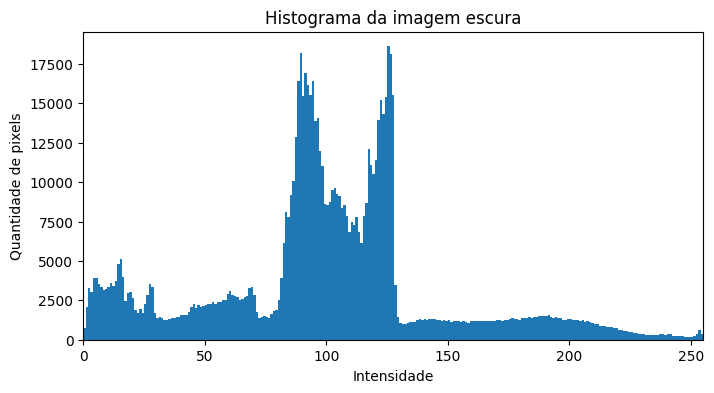

In [2]:
img1_rgb, img1 = carregar_cinza("foto_escura.jpg", 153, 1382)
mostrar_histograma(img1, "Histograma da imagem escura")

**Diagnóstico:** o histograma apresenta maior concentração de intensidades nos tons baixos e médios, principalmente aproximadamente entre 60 e 130, com pouca presença nas intensidades mais altas. Isso indica uma imagem predominantemente escura, com poucas regiões muito claras.

**Operação escolhida:** correção de gamma com **γ = 0,70**. Como γ < 1, os tons escuros e médios são elevados, clareando a imagem sem obrigar todo o histograma a ocupar o intervalo completo.

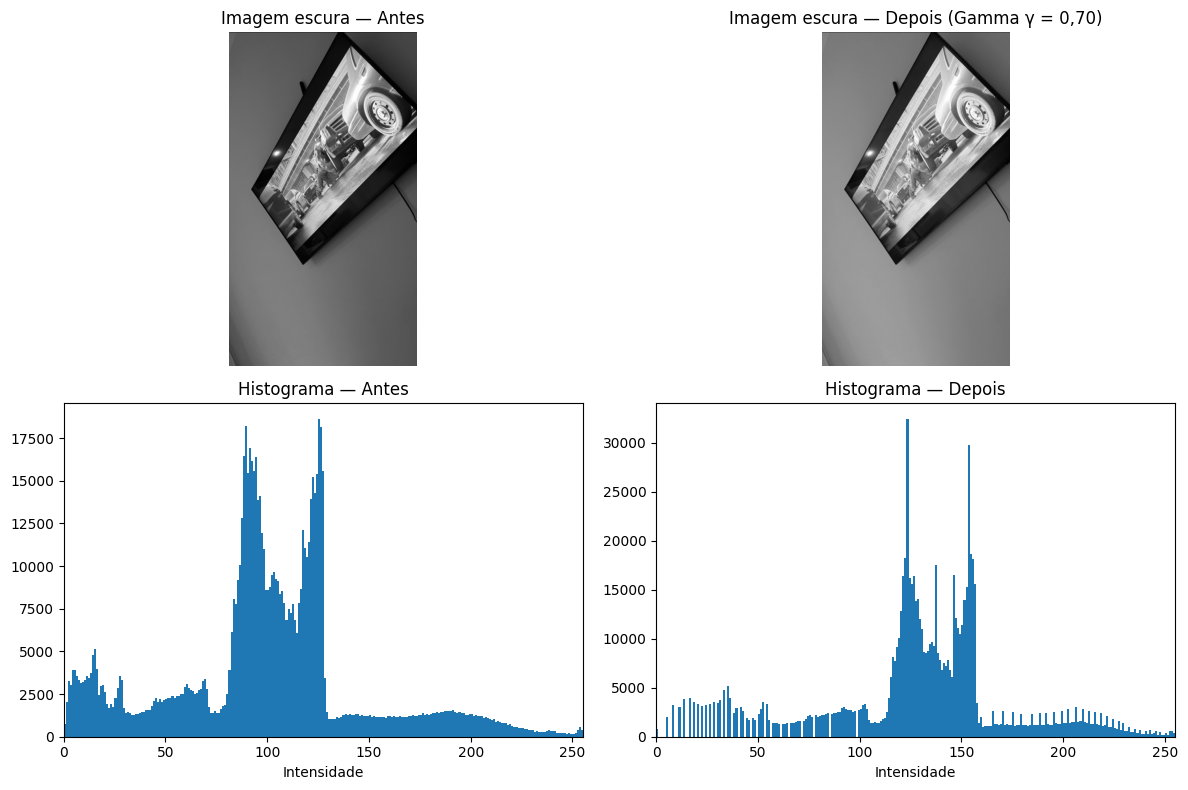

In [3]:
img1_corrigida = corrigir_gamma(img1, 0.70)
comparar(img1, img1_corrigida, "Imagem escura", "Gamma γ = 0,70")

## 2. Imagem clara / flash forte

Nesta imagem, o flash ilumina diretamente o gato, produzindo regiões claras no primeiro plano e contraste forte com o fundo.

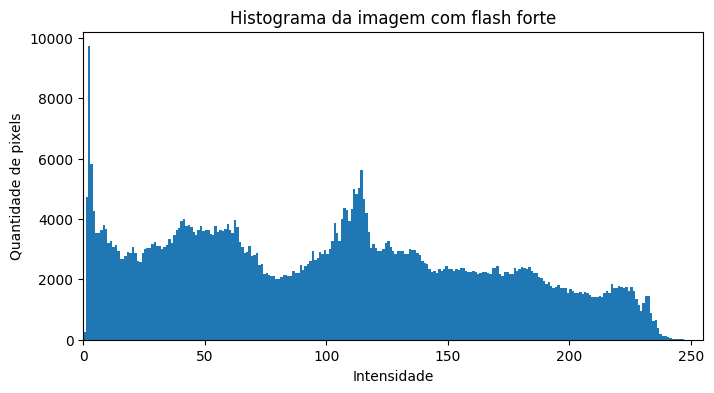

In [4]:
img2_rgb, img2 = carregar_cinza("foto_clara_flash.jpg", 307, 1230)
mostrar_histograma(img2, "Histograma da imagem com flash forte")

**Diagnóstico:** o histograma é bastante espalhado, mas apresenta uma parcela relevante de pixels em intensidades altas, acima de aproximadamente 190, causada principalmente pela iluminação direta do flash. Ao mesmo tempo, o fundo mantém muitos pixels escuros, mostrando o contraste forte entre o objeto iluminado e o ambiente.

**Operação escolhida:** correção de gamma com **γ = 1,20**. Como γ > 1, a transformação reduz principalmente os tons médios e claros, diminuindo o efeito de luminosidade excessiva provocado pelo flash.

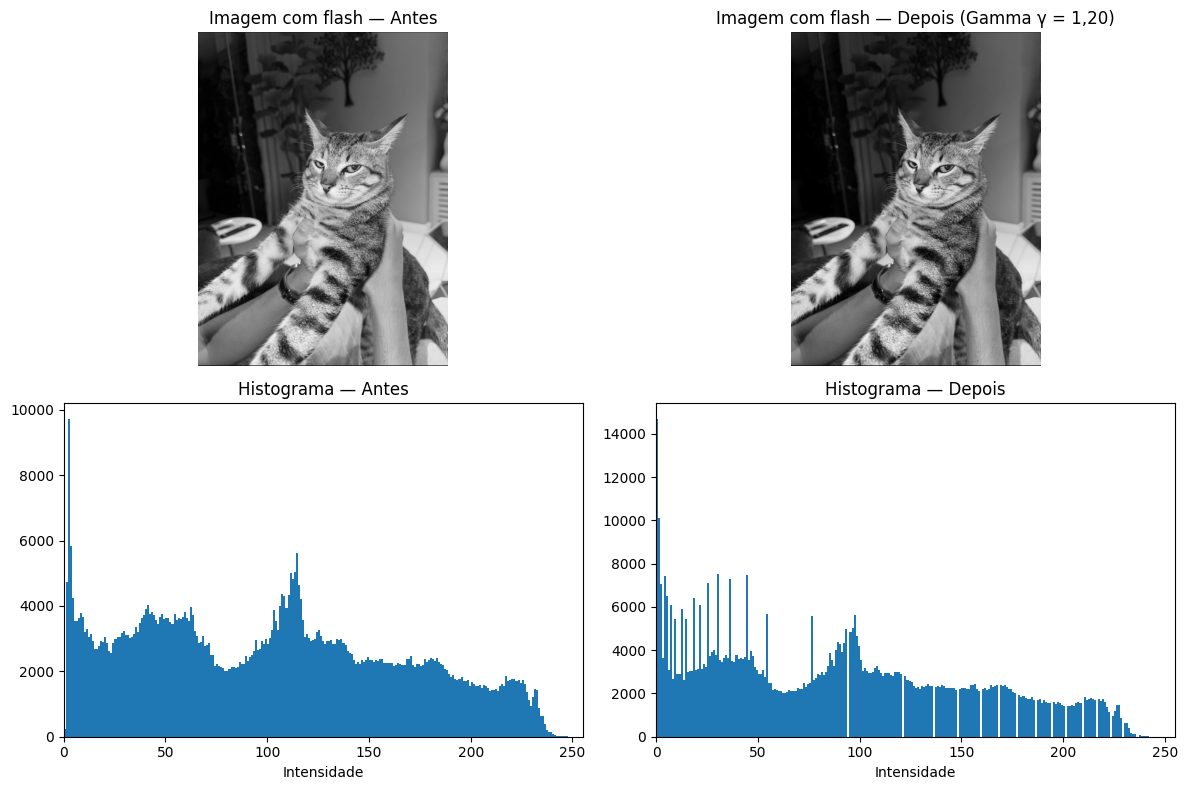

In [5]:
img2_corrigida = corrigir_gamma(img2, 1.20)
comparar(img2, img2_corrigida, "Imagem com flash", "Gamma γ = 1,20")

## 3. Imagem bem exposta

A terceira imagem apresenta detalhes tanto nas regiões mais escuras quanto nas mais claras, sem predomínio extremo de apenas uma faixa de intensidade.

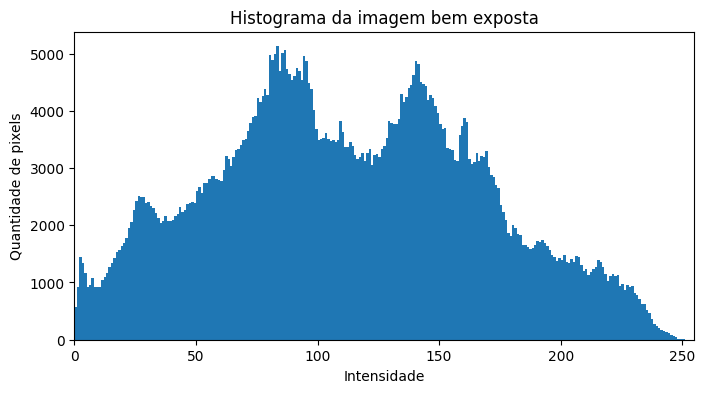

In [6]:
img3_rgb, img3 = carregar_cinza("foto_bem_exposta.jpg", 307, 1230)
mostrar_histograma(img3, "Histograma da imagem bem exposta")

**Diagnóstico:** as intensidades estão distribuídas por uma faixa ampla do histograma, com presença significativa de tons escuros, médios e claros. Essa distribuição indica uma exposição mais equilibrada, preservando detalhes em diferentes regiões da imagem.

**Operação escolhida:** expansão de contraste com **L = 5** e **H = 230**. Esses limites ficam próximos dos extremos já ocupados pela imagem, portanto a transformação amplia levemente a faixa tonal sem alterar de forma agressiva uma imagem que já apresenta bom contraste.

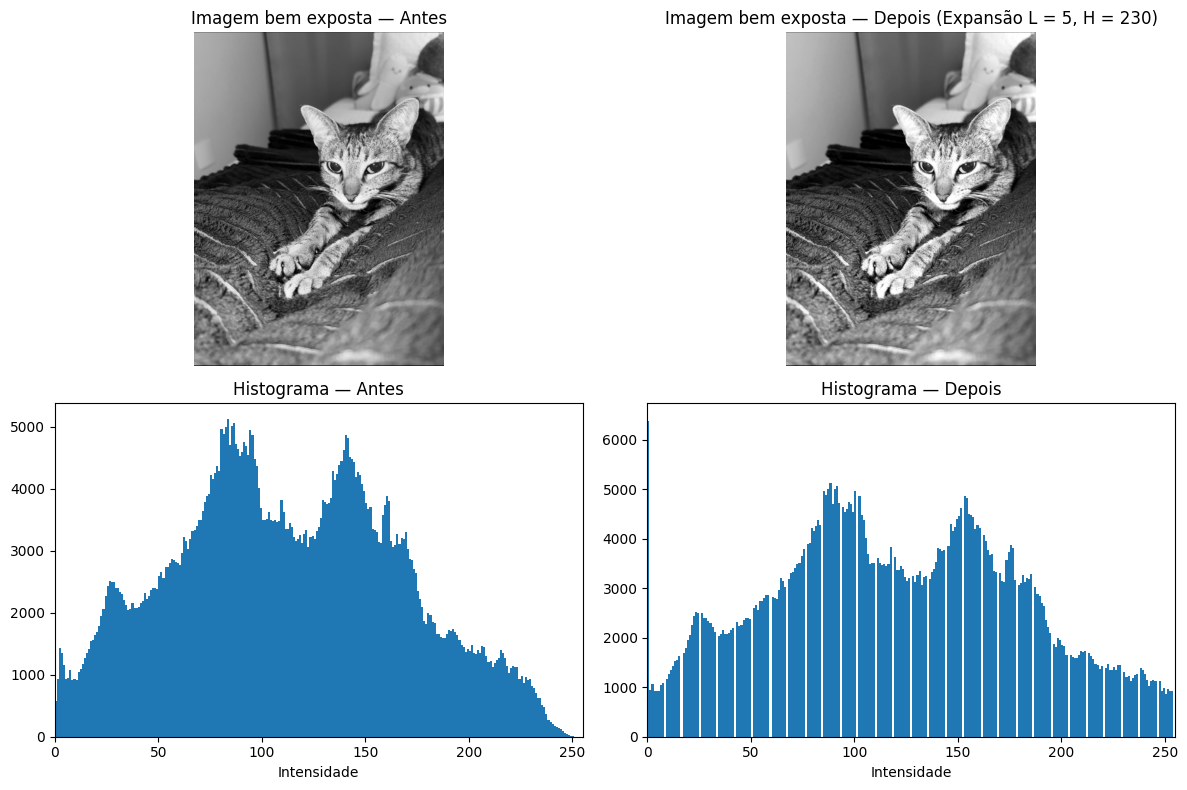

In [7]:
img3_corrigida = expandir_contraste(img3, 5, 230)
comparar(img3, img3_corrigida, "Imagem bem exposta", "Expansão L = 5, H = 230")

## Conclusão

A operação fez **menos diferença na imagem bem exposta**, porque ela já possuía uma distribuição relativamente ampla e equilibrada de intensidades, com detalhes visíveis em regiões escuras, médias e claras. Por isso, a expansão de contraste usando limites próximos dos extremos do histograma apenas aumentou levemente a separação entre os tons. Nas outras duas imagens havia um problema mais evidente de iluminação — pouca luminosidade na primeira e iluminação forte de flash na segunda —, fazendo com que a correção de gamma provocasse uma mudança visual maior.